In [ ]:
import os

file_name = "Relabelled_Cleaned_Dataset.csv"

# Check if the file already exists
if not os.path.exists(file_name):
    print(f"'{file_name}' not found. Downloading and unzipping dataset...")
    !kaggle datasets download -d ayush120/multiclass-suicidal-ideation-dataset
    !unzip multiclass-suicidal-ideation-dataset.zip
    # Rename if the unzipped file has a different name (based on previous interaction)
    if os.path.exists('Relabelled_Cleaned_Dataset.csv') and file_name != 'Relabelled_Cleaned_Dataset.csv':
        os.rename('Relabelled_Cleaned_Dataset.csv', file_name)
else:
    print(f"'{file_name}' already exists. Skipping download and unzip.")

'Relabelled_Cleaned_Dataset.csv' not found. Downloading and unzipping dataset...
Dataset URL: https://www.kaggle.com/datasets/ayush120/multiclass-suicidal-ideation-dataset
License(s): unknown
100% 23.1M/23.1M [00:02<00:00, 9.31MB/s]

Archive:  multiclass-suicidal-ideation-dataset.zip
  inflating: Relabelled_Cleaned_Dataset.csv  


In [ ]:
import pandas as pd
import os
import re
import json
import logging
import nltk
from pathlib import Path

df = pd.read_csv("Relabelled_Cleaned_Dataset.csv")
df.head()


,text,label
0,cuprohastes don t feed car milky way though th...,0
1,Question - Has anyone else struggled with want...,2
2,The new icons look like shit Seriously they do...,0
3,i dont know anymore so the story is i became f...,0
4,currently in hospital after attempting suicide...,2


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()


,text,clean_text
0,cuprohastes don t feed car milky way though th...,cuprohastes don t feed car milky way though th...
1,Question - Has anyone else struggled with want...,question has anyone else struggled with wantin...
2,The new icons look like shit Seriously they do...,the new icons look like shit seriously they do...
3,i dont know anymore so the story is i became f...,i dont know anymore so the story is i became f...
4,currently in hospital after attempting suicide...,currently in hospital after attempting suicide...


In [ ]:
# Calculate the length of each clean_text (word count)
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

# Display statistics for text length
print("--- Text Length Statistics (Word Count) ---")
print(f"Average text length: {df['text_length'].mean():.2f} words")
print(f"Standard deviation of text length: {df['text_length'].std():.2f} words")
print(f"Longest text: {df['text_length'].max()} words")
print(f"Shortest text: {df['text_length'].min()} words")

--- Text Length Statistics (Word Count) ---
Average text length: 146.79 words
Standard deviation of text length: 224.18 words
Longest text: 7612 words
Shortest text: 0 words


In [ ]:
label_map = {0: "no_risk", 1: "low_risk", 2: "high_risk"}
df["label_name"] = df["label"].map(label_map)
df.head()


,text,label,clean_text,text_length,label_name
0,cuprohastes don t feed car milky way though th...,0,cuprohastes don t feed car milky way though th...,26,no_risk
1,Question - Has anyone else struggled with want...,2,question has anyone else struggled with wantin...,194,high_risk
2,The new icons look like shit Seriously they do...,0,the new icons look like shit seriously they do...,36,no_risk
3,i dont know anymore so the story is i became f...,0,i dont know anymore so the story is i became f...,60,no_risk
4,currently in hospital after attempting suicide...,2,currently in hospital after attempting suicide...,23,high_risk


### Label Distribution

### Label Distribution Table with Examples

In [ ]:
import pandas as pd

# Count the occurrences of each label
label_counts = df['label_name'].value_counts().sort_index()

# Calculate percentages
total_samples = df.shape[0]
label_percentages = (label_counts / total_samples) * 100

# Prepare data for the table
label_data = []
for label_name, count in label_counts.items():
    percentage = label_percentages[label_name]

    # Get an example text for each label
    example_text = df[df['label_name'] == label_name]['text'].iloc[2470]

    label_data.append({
        'Label': label_name,
        'Count': count,
        'Percentage': f'{percentage:.2f}%',
        'Example': example_text
    })

# Create a DataFrame from the collected data
label_distribution_df = pd.DataFrame(label_data)

# Display the DataFrame
display(label_distribution_df)

,Label,Count,Percentage,Example
0,high_risk,30700,37.50%,Everything is fucking disgustingThe sink is di...
1,low_risk,20467,25.00%,Such a painI am a high school freshman in a th...
2,no_risk,30700,37.50%,I just want an antique skin lampshade from WW2...


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)

train_df.shape, test_df.shape


((65493, 5), (16374, 5))

In [ ]:
from collections import Counter
import itertools
from nltk.corpus import stopwords
import nltk

# Download stopwords if not already downloaded (ensure it's done before use)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Define English stopwords and add specific common words to exclude
stop_words_for_analysis = set(stopwords.words('english'))
stop_words_for_analysis.update(['i', 'to', 'and', 'the', 'my', 'a', 'me', 'of', 'it', 'that', 'in', 'but', 'for', 'have', 'is', 'just', "i'm", 'this', 'so', 'was'])

# Filter for high-risk texts
high_risk_texts = df[df['label_name'] == 'high_risk']['clean_text'].tolist()

# Tokenize and flatten the list of words, then filter out stop words
filtered_high_risk_words = [
    word for text in high_risk_texts
    for word in text.split()
    if word not in stop_words_for_analysis
]

# Count word frequencies
word_counts = Counter(filtered_high_risk_words)

# Get the top N common high-risk keywords
top_n = 10 # You can adjust this number
common_high_risk_keywords = word_counts.most_common(top_n)

print(f"\n--- Top {top_n} Common High-Risk Keywords (Word Frequency, filtered) ---")
for word, count in common_high_risk_keywords:
    print(f"'{word}': {count}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



--- Top 10 Common High-Risk Keywords (Word Frequency, filtered) ---
'want': 33854
'like': 32854
'life': 28489
'know': 27243
'feel': 26753
'get': 20851
'even': 19237
'people': 18676
'would': 17870
'time': 17773


## Word Cloud Visualization for Each Risk Category

In [ ]:
# Install and import necessary libraries
!pip install wordcloud
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Define English stopwords
stop_words = set(stopwords.words('english'))

# Add some common words observed in previous analysis that might not be in default stopwords
stop_words.update(['i', 'to', 'and', 'the', 'my', 'a', 'me', 'of', 'it', 'that', 'in', 'but', 'for', 'have', 'is', 'just', 'i\'m', 'this', 'so', 'was', 'cum', 'fuck', 'filler'])

def generate_wordcloud(text_corpus, title, stopwords=None):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords,
        min_font_size=10
    ).generate(text_corpus)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=15)
    plt.show()

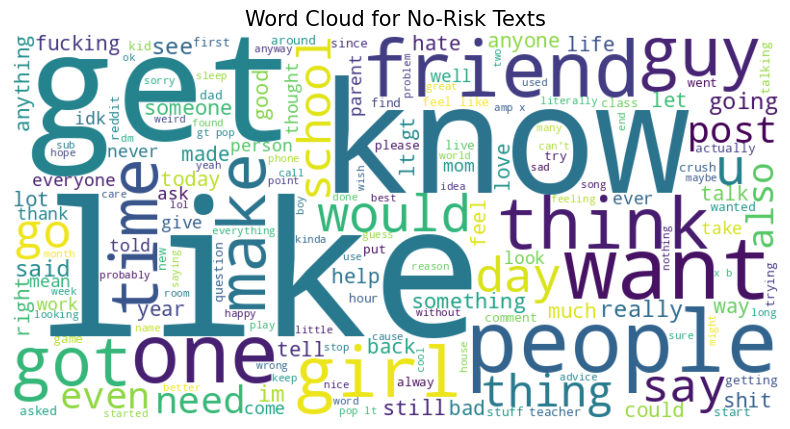

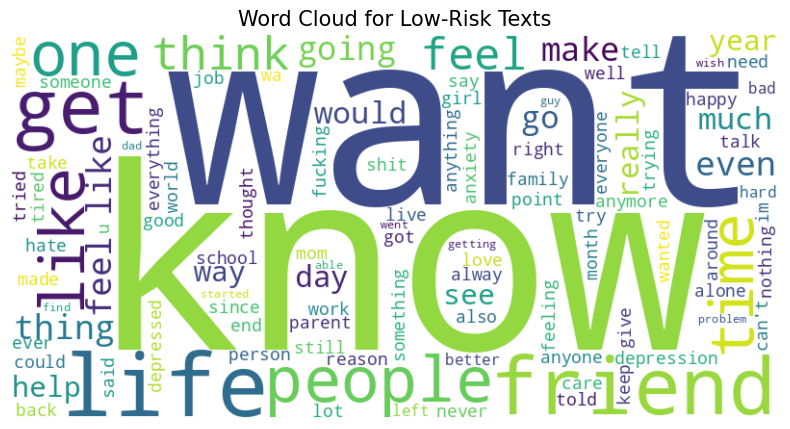

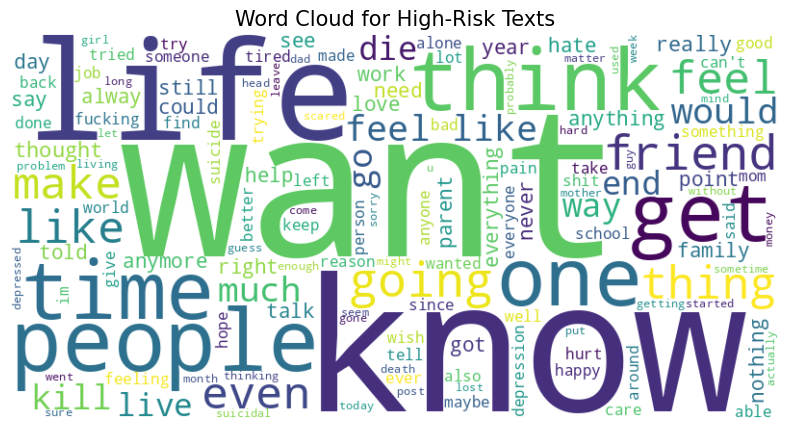

In [ ]:
# Prepare text data for each risk category
no_risk_text = ' '.join(df[df['label_name'] == 'no_risk']['clean_text'].tolist())
low_risk_text = ' '.join(df[df['label_name'] == 'low_risk']['clean_text'].tolist())
high_risk_text = ' '.join(df[df['label_name'] == 'high_risk']['clean_text'].tolist())

# Generate and display word cloud for 'no_risk' category
generate_wordcloud(no_risk_text, 'Word Cloud for No-Risk Texts', stopwords=stop_words)

# Generate and display word cloud for 'low_risk' category
generate_wordcloud(low_risk_text, 'Word Cloud for Low-Risk Texts', stopwords=stop_words)

# Generate and display word cloud for 'high_risk' category
generate_wordcloud(high_risk_text, 'Word Cloud for High-Risk Texts', stopwords=stop_words)

# Baseline：TF‑IDF + Logistic Regression


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# Use cleaned text as input
X_train = train_df["clean_text"]
y_train = train_df["label"]

X_test = test_df["clean_text"]
y_test = test_df["label"]

# Build TF-IDF + Logistic Regression
baseline_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30000,
        ngram_range=(1,2),
        sublinear_tf=True
    )),
    ("logreg", LogisticRegression(
        max_iter=300,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Train the model
baseline_clf.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=300,
                                    n_jobs=-1))])

In [ ]:
y_pred = baseline_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))


Accuracy: 0.867594967631611

Classification Report:

              precision    recall  f1-score   support

           0     0.9009    0.9489    0.9242      6140
           1     0.8015    0.8312    0.8161      4094
           2     0.8792    0.8106    0.8435      6140

    accuracy                         0.8676     16374
   macro avg     0.8605    0.8636    0.8613     16374
weighted avg     0.8679    0.8676    0.8669     16374



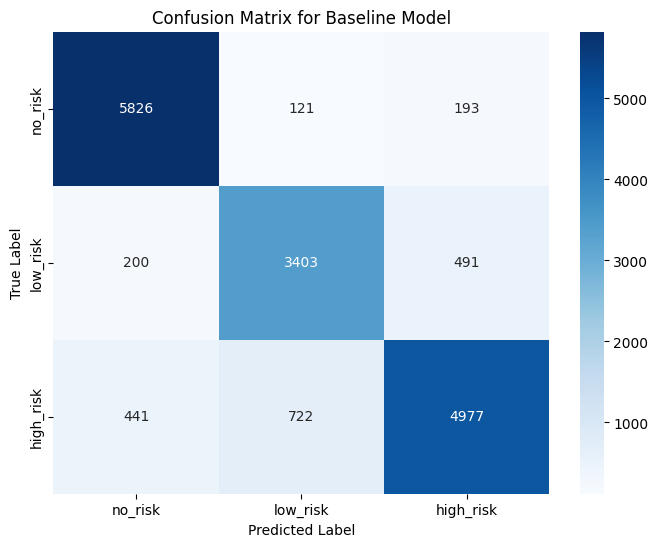

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.values(), yticklabels=label_map.values())
plt.title('Confusion Matrix for Baseline Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Show Top Words for Each Class (XAI)

In [ ]:
import numpy as np

tfidf = baseline_clf.named_steps["tfidf"]
logreg = baseline_clf.named_steps["logreg"]

feature_names = np.array(tfidf.get_feature_names_out())

for class_id, class_name in [(0,"no_risk"), (1,"low_risk"), (2,"high_risk")]:
    print(f"\n=== Top words for class {class_id} ({class_name}) ===")
    coef = logreg.coef_[class_id]
    top_idx = np.argsort(coef)[-20:]   # top 20
    print(feature_names[top_idx])



=== Top words for class 0 (no_risk) ===
['nut' 'teenagers' 'yo' 'horny' 'yall' 'reddit' 'karma' 'girl' 'why is'
 'trump' 'discord' 'nnn' 'cool' 'tho' 'we' 'ur' 'minecraft' 'crush' 'guys'
 'bored']

=== Top words for class 1 (low_risk) ===
['esteem' 'self esteem' 'ha' 'health' 'isolated' 'feeling down' 'rt'
 'medication' 'mental health' 'breakdown' 'hopeless' 'wa' 'therapist'
 'worthless' 'anxious' 'anxiety' 'depressed' 'crying' 'lonely'
 'depression']

=== Top words for class 2 (high_risk) ===
['end it' 'pills' 'mei' 'hang myself' 'to kill' 'end my' 'harm' 'overdose'
 'life' 'myself' 'about suicide' 'die' 'thoughts' 'self harm'
 'suicidal thoughts' 'to die' 'kill' 'kill myself' 'suicide' 'suicidal']


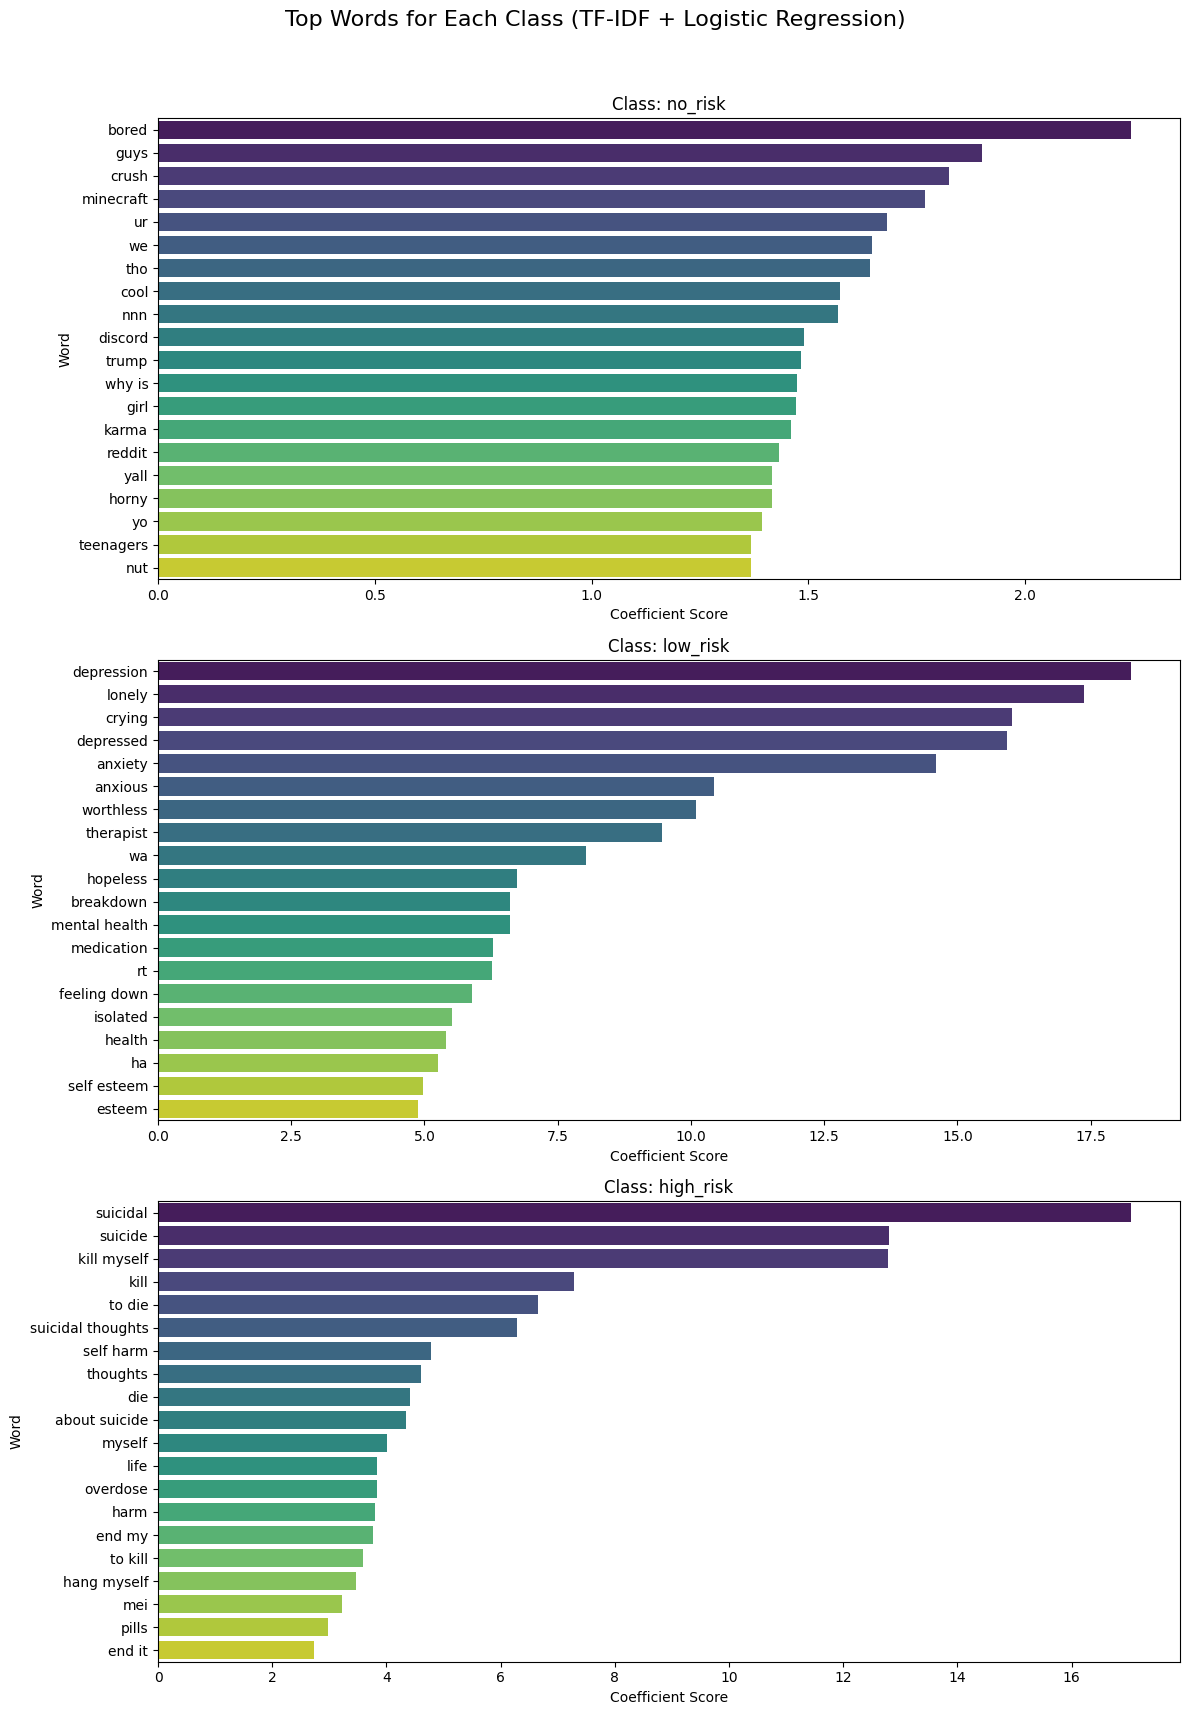

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature names from the TF-IDF vectorizer
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle('Top Words for Each Class (TF-IDF + Logistic Regression)', fontsize=16)

for i, (class_id, class_name) in enumerate([(0, "no_risk"), (1, "low_risk"), (2, "high_risk") ]):
    coef = logreg.coef_[class_id]
    # Get top 20 words (positive coefficients indicate association with the class)
    top_20_indices = np.argsort(coef)[-20:]
    top_20_words = feature_names[top_20_indices]
    top_20_scores = coef[top_20_indices]

    # Create a DataFrame for easy plotting
    df_plot = pd.DataFrame({
        'Word': top_20_words,
        'Score': top_20_scores
    })
    df_plot = df_plot.sort_values('Score', ascending=False)

    # Address FutureWarning by assigning 'Word' to hue and setting legend=False
    sns.barplot(x='Score', y='Word', hue='Word', data=df_plot, palette='viridis', ax=axes[i], legend=False)
    axes[i].set_title(f'Class: {class_name}')
    axes[i].set_xlabel('Coefficient Score')
    axes[i].set_ylabel('Word')

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent title overlap
plt.show()

# BERT

In [ ]:

!pip install -U transformers accelerate datasets

from datasets import Dataset

# Convert pandas DataFrame to HuggingFace Dataset
train_ds = Dataset.from_pandas(train_df[["clean_text", "label"]])
test_ds = Dataset.from_pandas(test_df[["clean_text", "label"]])

# Load Tokenizer
from transformers import AutoTokenizer

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

# Set format for PyTorch
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/65493 [00:00<?, ? examples/s]

Map:   0%|          | 0/16374 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3  # 0=no risk, 1=low risk, 2=high risk
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# Define evaluation metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./bert_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

## training

In [ ]:
trainer.train()
trainer.evaluate()


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.277437,0.282975,0.887688,0.878559
2,0.221716,0.288347,0.887688,0.880547
3,0.132290,0.346196,0.891230,0.883758


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.132290,0.346196,3,0.891230,0.883758


{'eval_loss': 0.3461964726448059,
 'eval_accuracy': 0.8912299987785514,
 'eval_macro_f1': 0.8837580414222238}

# save model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/bert_suicide_model"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)


Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/bert_suicide_model/tokenizer_config.json',
 '/content/drive/MyDrive/bert_suicide_model/tokenizer.json')

# Load Model

In [ ]:
from google.colab import drive
from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer
import os
drive.mount('/content/drive')
load_path = "/content/drive/MyDrive/bert_suicide_model"

# Optional: Print directory contents for debugging
print(f"Contents of {load_path}:")
try:
    for item in os.listdir(load_path):
        print(item)
except FileNotFoundError:
    print(f"Directory {load_path} not found. Please ensure it exists and is accessible.")
    # Exit or raise an error if the directory isn't found
    raise FileNotFoundError(f"Directory {load_path} not found.")
except Exception as e:
    print(f"An error occurred while listing directory contents: {e}")


# Explicitly load config first, forcing local files only
# This can sometimes help ensure the library correctly identifies the path as local
config = AutoConfig.from_pretrained(load_path, local_files_only=True)
config.output_attentions = True # Set output_attentions directly in the config

# Load the model with attention outputs enabled, passing the loaded config
model = AutoModelForSequenceClassification.from_pretrained(
    load_path,
    config=config, # Pass the updated config
    attn_implementation="eager",
    local_files_only=True
)
tokenizer = AutoTokenizer.from_pretrained(load_path, local_files_only=True)

print("Model and tokenizer loaded successfully from local path.")

Mounted at /content/drive
Contents of /content/drive/MyDrive/bert_suicide_model:
config.json
model.safetensors
tokenizer_config.json
tokenizer.json


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model and tokenizer loaded successfully from local path.


# Evaluation

Predicting probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

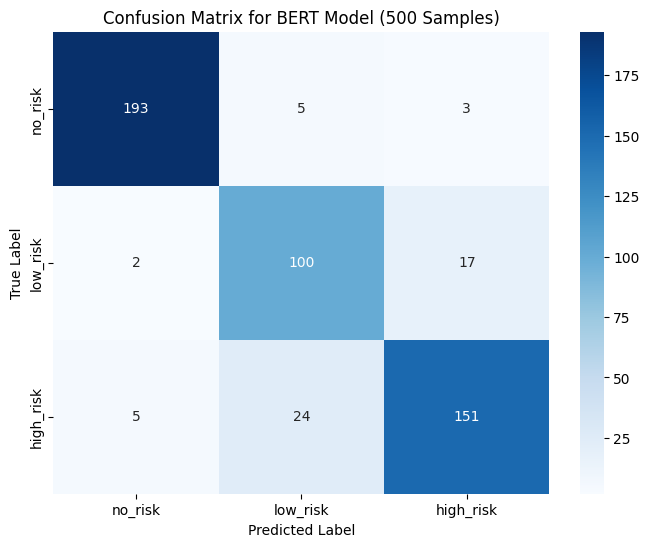

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm # Import tqdm
import random # Import random for sampling

# BERT prediction wrapper for LIME and Confusion Matrix
def predict_proba(texts, batch_size=32): # Added batch_size argument
    all_probs = []
    # Loop over texts in batches with a progress bar
    for i in tqdm(range(0, len(texts), batch_size), desc="Predicting probabilities"):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = model(
                input_ids=inputs["input_ids"].to(model.device),
                attention_mask=inputs["attention_mask"].to(model.device)
            )
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs) # Stack all batch probabilities

# Get predictions from the model on the test set
# Since predict_proba expects a list of texts, extract 'clean_text' from test_df
# Sample 500 texts for faster processing
sampled_indices = random.sample(range(len(test_df)), min(500, len(test_df))) # Take a random sample
sampled_test_df = test_df.iloc[sampled_indices]

X_test_texts_sampled = sampled_test_df['clean_text'].tolist()

# Get probabilities for each class
probabilities_sampled = predict_proba(X_test_texts_sampled)

# Get predicted labels by taking the argmax of probabilities
y_pred_bert_sampled = np.argmax(probabilities_sampled, axis=1)

# Get true labels from the sampled test_df
y_true_bert_sampled = sampled_test_df['label'].values

# Compute the confusion matrix
cm_bert = confusion_matrix(y_true_bert_sampled, y_pred_bert_sampled)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.values(), yticklabels=label_map.values())
plt.title('Confusion Matrix for BERT Model (500 Samples)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
import pandas as pd

# Combine sampled data with true and predicted labels
results_df = sampled_test_df.copy()
results_df['true_label_id'] = y_true_bert_sampled
results_df['predicted_label_id'] = y_pred_bert_sampled
results_df['true_label_name'] = results_df['true_label_id'].map(label_map)
results_df['predicted_label_name'] = results_df['predicted_label_id'].map(label_map)

# --- False Negatives (FN) for 'high_risk' class ---
# True label is high_risk (2), but predicted as no_risk (0) or low_risk (1)
false_negatives_high_risk = results_df[
    (results_df['true_label_id'] == 2) &
    (results_df['predicted_label_id'] != 2)
]

print("\n--- False Negatives (True High Risk, Predicted Other) ---")
if not false_negatives_high_risk.empty:
    for idx, row in false_negatives_high_risk.head(5).iterrows():
        print(f"Original Text: {row['text'][:200]}...")
        print(f"Clean Text: {row['clean_text'][:200]}...")
        print(f"True Label: {row['true_label_name']}")
        print(f"Predicted Label: {row['predicted_label_name']}")
        print("---\n")
else:
    print("No False Negatives for 'high_risk' found in sampled data.")

# --- False Positives (FP) for 'high_risk' class ---
# True label is no_risk (0) or low_risk (1), but predicted as high_risk (2)
false_positives_high_risk = results_df[
    (results_df['true_label_id'] != 2) &
    (results_df['predicted_label_id'] == 2)
]

print("\n--- False Positives (Predicted High Risk, True Other) ---")
if not false_positives_high_risk.empty:
    for idx, row in false_positives_high_risk.head(5).iterrows():
        print(f"Original Text: {row['text'][:200]}...")
        print(f"Clean Text: {row['clean_text'][:200]}...")
        print(f"True Label: {row['true_label_name']}")
        print(f"Predicted Label: {row['predicted_label_name']}")
        print("---\n")
else:
    print("No False Positives for 'high_risk' found in sampled data.")


--- False Negatives (True High Risk, Predicted Other) ---
Original Text: I feel like I can't handle this anymoreI don't know who to talk to or what to say anyway. 

The only reason I can't actually go through with it is because of my boyfriend and my dog. Sounds stupid, bu...
Clean Text: i feel like i can't handle this anymorei don't know who to talk to or what to say anyway the only reason i can't actually go through with it is because of my boyfriend and my dog sounds stupid but it'...
True Label: high_risk
Predicted Label: low_risk
---

Original Text: I feel lost.I'm failing pretty much every class in university, mostly because I just don't know how to sit down for a couple of hours a day and study for my classes, which probably stems from me never...
Clean Text: i feel lost i'm failing pretty much every class in university mostly because i just don't know how to sit down for a couple of hours a day and study for my classes which probably stems from me never a...
True Label: high_r

# LIME for BERT

In [ ]:
!pip install lime


In [ ]:
from lime.lime_text import LimeTextExplainer

class_names = ["no_risk", "low_risk", "high_risk"]
explainer = LimeTextExplainer(class_names=class_names)


In [ ]:
i = 25 # choose any test sample
text_to_explain = test_df.iloc[i]["clean_text"]
label = test_df.iloc[i]["label"]

print("TEXT:", text_to_explain)
print("TRUE LABEL:", class_names[label])


TEXT: need advice for the next few days even though my life on one side seems to be improving i am experiencing more frequent desire to escape life through suicide it has been almost every day this week i have many worries some of them are probably overblown but others might be legitimate i have lifelong depression and i can't seem to take care of myself it takes a lot of effort to even do one thing a day if it means leaving my apartment i am usually very poor and i live in a lousy apartment in a gang neighborhood and i am worried about that i'm worried that the girl i like may actually like me back and i have a lot of fears about getting my heart broken because i lose my mind i lose all preference of living or dying when that happens i am currently suicidal but i think if i'm careful i will make it through the night what i need is some advice for the next few days because i am worried about the progression of these thoughts if this keeps up thanks for helping
TRUE LABEL: high_risk


In [ ]:
exp = explainer.explain_instance(
    text_to_explain,
    predict_proba,
    num_features=10,      # top 10 important tokens
    num_samples=500,      # Reduce the number of samples to decrease memory usage
    labels=[0, 1, 2]      # explain all classes
)
exp.show_in_notebook(text=True)

Predicting probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

This is the core of the LIME explanation. We call `explainer.explain_instance` with the following parameters:
- `text_to_explain`: The specific text for which we want an explanation.
- `predict_proba`: Our model's prediction function that takes a list of texts and returns the probability distribution over the classes. This function was defined earlier in the notebook.
- `num_features=10`: We want to see the top 10 most important words contributing to the prediction.
- `num_samples=500`: LIME generates `num_samples` perturbed versions of the input text to build the local interpretable model. A smaller number here means faster computation but potentially less stable explanations. The comment mentions reducing it to decrease memory usage, which is a practical consideration.
- `labels=[0, 1, 2]`: We want explanations for all three classes (no_risk, low_risk, high_risk).



In [ ]:
import numpy as np

pred_class = np.argmax(predict_proba([text_to_explain])[0])
print("PREDICTED:", class_names[pred_class])

exp.as_list(label=pred_class)

Predicting probabilities:   0%|          | 0/1 [00:00<?, ?it/s]

PREDICTED: high_risk


[(np.str_('suicide'), 0.32808521190051587),
 (np.str_('suicidal'), 0.24607089968862703),
 (np.str_('a'), -0.15010700924443923),
 (np.str_('currently'), 0.10485907922487638),
 (np.str_('effort'), 0.09771623488204913),
 (np.str_('one'), 0.09761752334734054),
 (np.str_('fears'), 0.09710312259779535),
 (np.str_('depression'), -0.09025933412505778),
 (np.str_('me'), -0.0617964583308566),
 (np.str_('lifelong'), -0.03233091460735633)]

# Attention Visualizing

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
def visualize_attention_avg(text, model, tokenizer, layer=0):
    """
    Visualize averaged attention across all heads in a given layer.
    Produces a smoother and more interpretable heatmap.
    """

    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64)
    input_ids = inputs["input_ids"].to(model.device)
    attention_mask = inputs["attention_mask"].to(model.device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True
        )

    # Average across all heads
    attn = outputs.attentions[layer][0].mean(dim=0).cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title(f"Attention Heatmap (Layer {layer}, Averaged Heads)")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()


TEXT: need a good reason not to end my lifehello r suicidewatch i'm years old right now and i'm thinking about killing myself life is just sadness and stress my parents don't think i'm good enough they always want more my friends are always trying to get rid of me i feel worthless sad and hopeless i'm not enough for anybody i really can't think of any way to escape this torture other than suicide


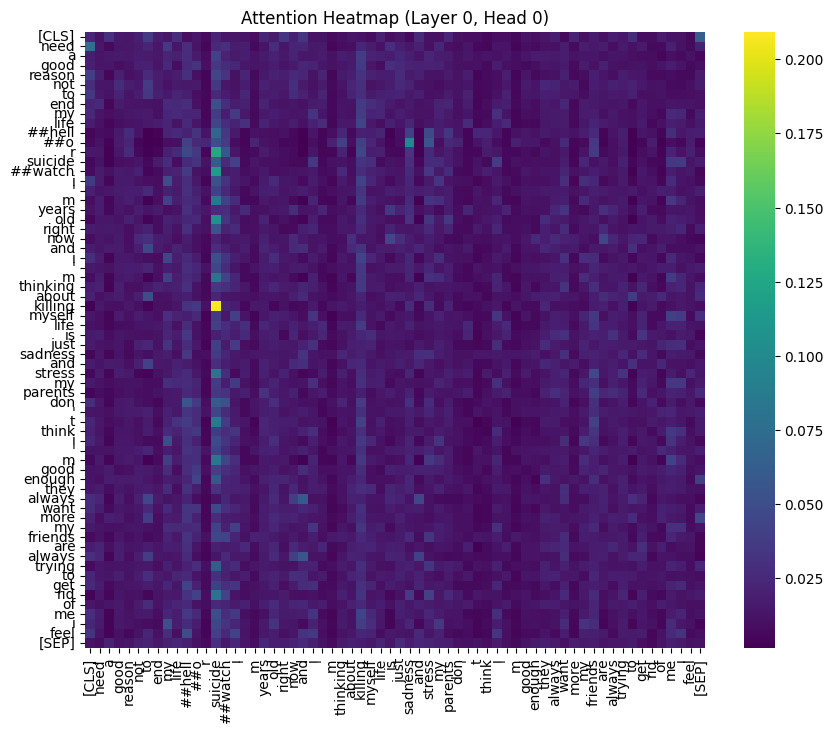

In [ ]:
i = 3  # choose any index from your test set
text = test_df.iloc[i]["clean_text"]

print("TEXT:", text)
visualize_attention(text, model, tokenizer, layer=0, head=0)


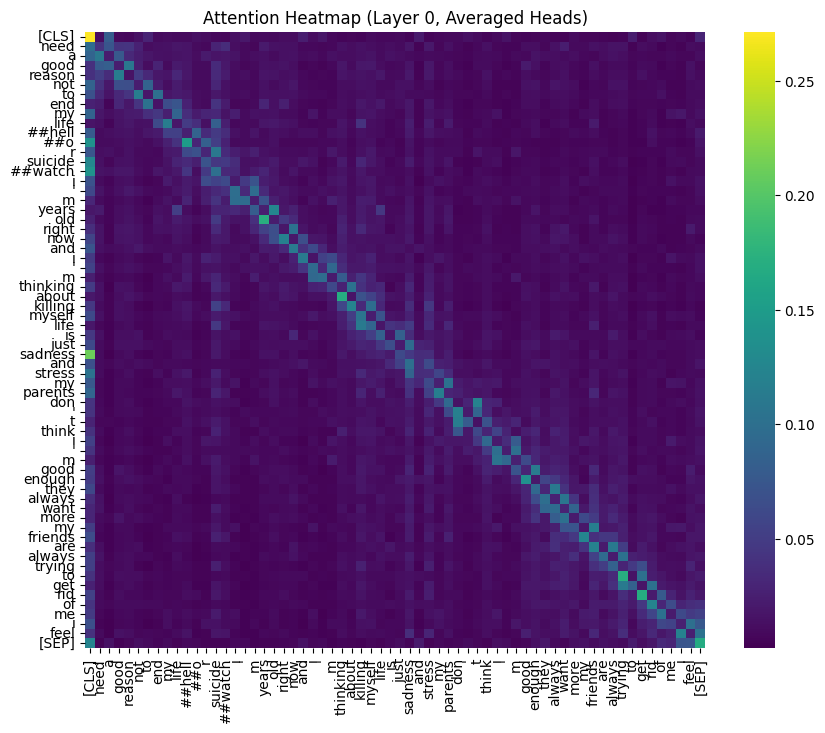

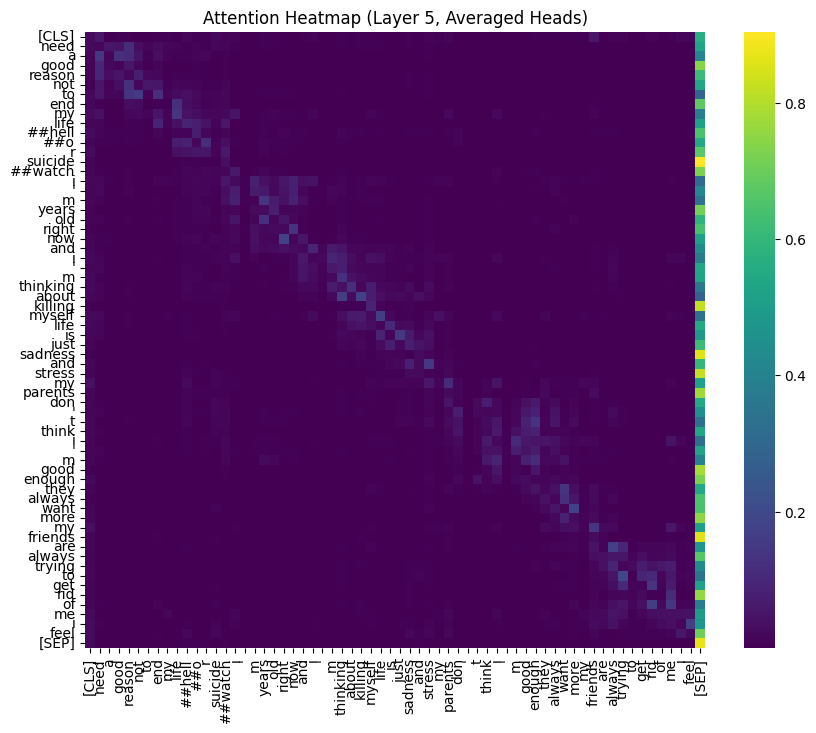

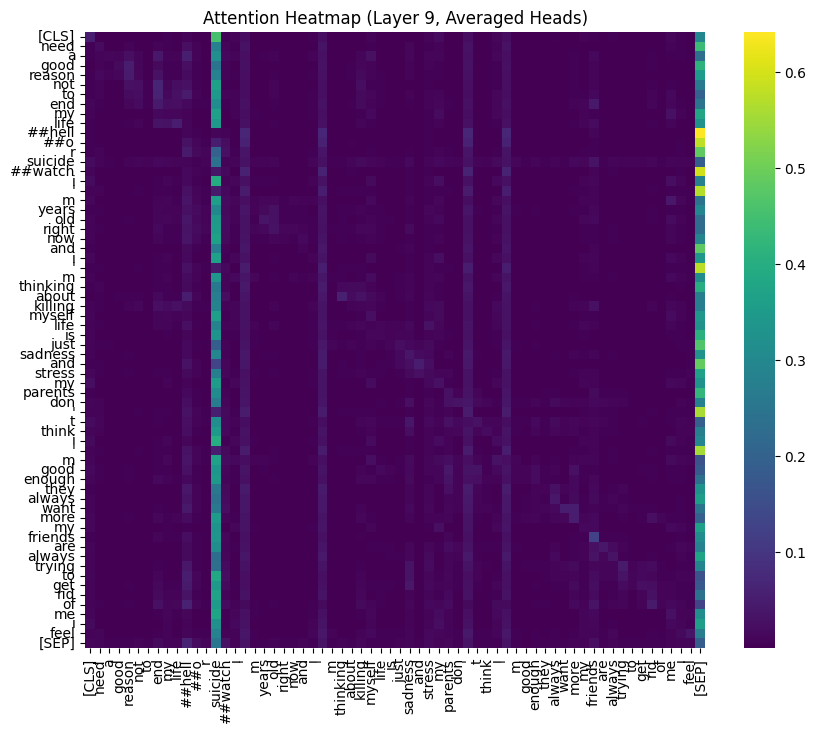

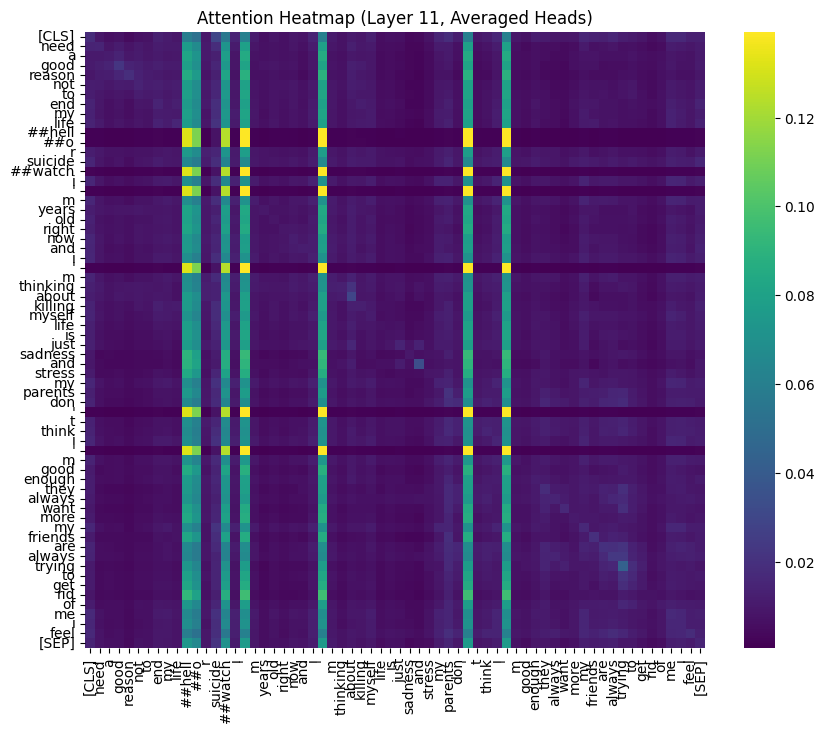

In [ ]:
for layer in [0, 5, 9, 11]:
    visualize_attention_avg(text, model, tokenizer, layer=layer)
